In [16]:
import torch
import torch.nn as nn
from   torch.utils.data import DataLoader
from   torchvision import datasets
from   torchvision.transforms import v2
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import csv

In [17]:
print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

2.13.0+cu130
True
NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


# CIFAR-10 Neural Network
The CIFAR-10 dataset is a collection of 60,000 32x32 images and their classes. There are ten classes in this dataset, ranging from plane to cat. The task of this project is to build a high-accuracy classification network to match unseen images to their class. <br>



## Loading The Dataset
CIFAR-10 is included in torchvision's dataset class so it may be easily downloaded.

In [18]:
def loadCIFAR() -> dict:
    batch_size = 64
    training_data = datasets.CIFAR10(
        root="data",
        train=True,
        download=True,
        transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    )

    test_data = datasets.CIFAR10(
        root="data",
        train=False,
        download=True,
        transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    )

    # create dataloaders
    training_dataloader = DataLoader(training_data, batch_size, shuffle=True)
    test_dataloader     = DataLoader(test_data, batch_size, shuffle=True)

    print("Loader creation successful!\n")

    # create dictionary for test and train sets, plus the batch size
    data_dict = {
        "batch_size": batch_size,
        "training": training_dataloader,
        "testing" : test_dataloader
    }

    # print shapes of images and labels
    for image, label in test_dataloader:
        print(f"Shape of image: [batch, colours, size, labels]: {image.shape}")
        print(f"Shape of label: [batch, datatype]: {label.shape} {label.dtype}\n")
        break

    return data_dict

data = loadCIFAR()

Loader creation successful!

Shape of image: [batch, colours, size, labels]: torch.Size([64, 3, 32, 32])
Shape of label: [batch, datatype]: torch.Size([64]) torch.int64



### Displaying The Data
Representing this data is easy, as it is image data and can be displayed with matplotlib. The title here is the correct class of that image.

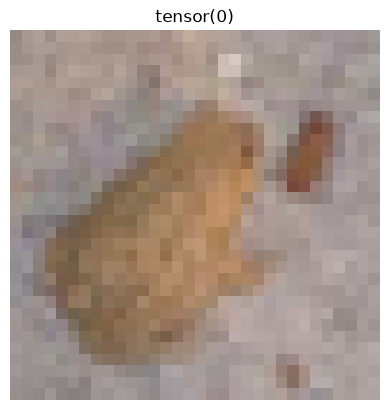

In [19]:
def DisplayData():
    images, labels = next(iter(data.get("training")))
    image = images[0]
    label = labels[0]
    # PyTorch: [channels, height, width]
    # Matplotlib: [height, width, channels]
    display_image = image.permute(1, 2, 0)
    plt.imshow(display_image)
    plt.title(labels[label.item()])
    plt.axis("off")
    plt.show()

DisplayData()

### Creating a Neural Network
This neural network is totally untrained and has two learnable layers and a nonnlinear activation function to enable to network to learn the nonlinear relationships these images may have with their labels. The layers are:
<li> 1. Linear hidden layer with 3x32x32 (3072) inputs and 128 outputs. </li>
<li> 2. ReLU nonlinear hidden activation function </li>
<li> 3. Output linear layer taking 128 inputs and ouputting 10 logits (1 per class) </li>

In [20]:
class CifarNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.flatten = nn.Flatten()

        self.layers = nn.Sequential(
            nn.Linear( 3 * 32 * 32, 128 ),
            nn.ReLU(),
            nn.Linear( 128, 10 )
        )
        self.loss = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.SGD(self.parameters(), lr=1e-3)

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

model   = CifarNetwork().to(device)

### Data Throughput Test
The following test will pass data from the training set through the untrained neural network. The outputs are essentially random due to this, but the evolution of the shape of the data can be followed. The image data first comes through as a four dimensional tensor, but the output of the network (the logits) are only two dimensional, with one of them being the ten logits at the end (one logit per class, and an image could potentially be any of them, so all ten represented as potential outcomes of every image.)

In [21]:
images, labels = next(iter(data.get("training")))
images = images.to(device)
labels = labels.to(device)
logits = model(images)
print("Image shape: ", images.shape)
print("Label shape: ", labels.shape)
print("Logit shape: ", logits.shape)

Image shape:  torch.Size([64, 3, 32, 32])
Label shape:  torch.Size([64])
Logit shape:  torch.Size([64, 10])


We can see there are 10 logits in the image result logit tensor. The greater the number, the higher the network has scored the class as belonging to the image. 

In [22]:
print("Image Class: ", logits[0])
print("Expected Class: ", labels[0])

Image Class:  tensor([ 0.0572,  0.0644,  0.2234,  0.3787,  0.1125,  0.0805,  0.2167, -0.2371,
        -0.0198,  0.0126], device='cuda:0', grad_fn=<SelectBackward0>)
Expected Class:  tensor(0, device='cuda:0')


Now we can find the logit with the highest score and return it.

In [23]:
predictions = logits.argmax(dim=1)
print("Prediction tensor shape: ", predictions.shape)
print("Prediction: ", predictions[0])
print("Expected  : ", labels[0])

Prediction tensor shape:  torch.Size([64])
Prediction:  tensor(3, device='cuda:0')
Expected  :  tensor(0, device='cuda:0')


### Loss Function
This a function that tells how wrong the models prediction was. This is an untrained network, so the loss will be high. The exact function used is cross-entropy loss.

In [24]:
loss_function = nn.CrossEntropyLoss()
loss = loss_function(logits, labels)

print("Loss", loss.item())

Loss 2.323269844055176


In [25]:
def train(dataloader, model):
    size    = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute Prediction Error
        pred = model(X)
        loss = model.loss(pred, y)

        # Backpropagation
        loss.backward()
        model.optimizer.step()
        model.optimizer.zero_grad()

        if batch % 100 == 0:    
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")  


def test(dataloader, model) -> list:
    size = len(dataloader.dataset)
    batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_function(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= batches
    correct   /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return [test_loss, (correct * 100)]


def test_train_loop(epochs, device, model):
    print(f"Using device: {device}")
    datasets = loadCIFAR()

    with open("logs/mlplog.csv", 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        data = [
            ['Epoch', 'Loss', 'Accuracy']
        ]
        writer.writerows(data)
    
        for t in range(epochs):
            print(f"\n\tEpoch {t+1} \n-------------------")
            train(datasets.get("training"), model)
            data = test(datasets.get("testing"), model)
            data.insert(0, t + 1)
            writer.writerow(data)

    time = str(datetime.datetime.now())
    model_name = "models/mlp/model_" + time.replace(" ", "-").replace(":", "-") + ".pth"

    torch.save(model.state_dict(), model_name)


test_train_loop(15, device, model)

Using device: cuda
Loader creation successful!

Shape of image: [batch, colours, size, labels]: torch.Size([64, 3, 32, 32])
Shape of label: [batch, datatype]: torch.Size([64]) torch.int64


	Epoch 1 
-------------------
loss: 2.298755  [   64/50000]
loss: 2.286981  [ 6464/50000]
loss: 2.270918  [12864/50000]
loss: 2.244904  [19264/50000]
loss: 2.223494  [25664/50000]
loss: 2.226088  [32064/50000]
loss: 2.242020  [38464/50000]
loss: 2.216803  [44864/50000]
Test Error: 
 Accuracy: 23.9%, Avg loss: 2.201339 


	Epoch 2 
-------------------
loss: 2.206360  [   64/50000]
loss: 2.232999  [ 6464/50000]
loss: 2.172981  [12864/50000]
loss: 2.198710  [19264/50000]
loss: 2.145926  [25664/50000]
loss: 2.184247  [32064/50000]
loss: 2.141171  [38464/50000]
loss: 2.152061  [44864/50000]
Test Error: 
 Accuracy: 27.1%, Avg loss: 2.115056 


	Epoch 3 
-------------------
loss: 2.157894  [   64/50000]
loss: 2.123587  [ 6464/50000]
loss: 2.136312  [12864/50000]
loss: 2.060623  [19264/50000]
loss: 2.159003

## Developing a Convolutional Neual Network

The network created above, even after 5 epochs, is still very ineffective. It's loss is around 1.95, and it only gets around 30% accuracy. After 15 epoch its loss is still 1.8 and has an accuracy of 36%. If we use a different architecture that is more suitable for image classification, however, we can increase this substantially. <br>

### Convolutions
Convolutions are small filter layers that process a small window of an image, in this case ```kernel_size=3```. These filters look in all channels defined in ```in_channels=3``` (here, it would be a tensor with the shape of ```[rgb_channels, height, width]```), resulting in a tensor with the shape of ```[features, height, width]```. These filters themselves are trained, and there is a 1:1 ratio of filter:output, with there being ```out_channels=32```. These 32 features maps are then fed into a nonlinear layer ```ReLU``` before going to the ```MaxPool2d``` layer. These features are no longer RGB or other pixel values but instead are representations of learned features in an image.

``` 
nn.Conv2d(
         in_channels  = 3,
         out_channels = 32,
         kernel_size  = 3,
         padding      = 1
    )
```

### Pooling
Pooling is broadly equivalent to compression of the image by retaining only the strongest activations in a scanned area. It does this by sampling a grid of each feature map and keeping only the strongest activation and moving over by a set amount of pixels called the stride to scan the next part of the image. This is defined simply its ```kernel_size = 2```, and if the ```stride``` is not specified then it will be the same value as the kernel size. In this case, the first pool will reduce the dimensions from ```[32, 32, 32]``` to ```[32, 16, 16]```, halving them. This compresses the spatial size of the feature maps down to a quarter of their  original size and allows the later layers to scan a wider area with the same kernel sizes due to this downsampling. The region of the original input that can influence a particular activation is called its receptive field. By downsampling the feature maps, pooling therefore increases the receptive field of subsequent layers.

In [26]:
class CifarNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Flattening removes the explicit 2D structure of the images pixels. The convolutions need these spatial dimensions intact
        
        self.layers = nn.Sequential(
            nn.Conv2d(
                in_channels  = 3,
                out_channels = 32,
                kernel_size  = 3,
                padding      = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size = 2
            ),

            nn.Conv2d(
                in_channels  = 32,
                out_channels = 64,
                kernel_size  = 3,
                padding      = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size = 2
            ),

            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.layers(x)

model   = CifarNetwork().to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=1e-3,
    momentum=0.9
)

### Training and Testing the CNN

In [27]:
def train(dataloader, model):
    size    = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute Prediction Error
        pred = model(X)
        loss = loss_function(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:    
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")  


def test(dataloader, model) -> list:
    size = len(dataloader.dataset)
    batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_function(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= batches
    correct   /= size
    print(f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return [test_loss, (100 * correct)]


def test_train_loop(epochs, device, model):
    print(f"Using device: {device}")
    datasets = loadCIFAR()

    with open("logs/cnnlog.csv", 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        data = [
            ['Epoch', 'Loss', 'Accuracy']
        ]
        writer.writerows(data)
    
        for t in range(epochs):
            print(f"\n\tEpoch {t+1} \n-------------------")
            train(datasets.get("training"), model)
            data = test(datasets.get("testing"), model)
            data.insert(0, t + 1)
            writer.writerow(data)

    time = str(datetime.datetime.now())
    model_name = "models/cnn/model_" + time.replace(" ", "-").replace(":", "-") + ".pth"

    torch.save(model.state_dict(), model_name)


test_train_loop(15, device, model)

Using device: cuda
Loader creation successful!

Shape of image: [batch, colours, size, labels]: torch.Size([64, 3, 32, 32])
Shape of label: [batch, datatype]: torch.Size([64]) torch.int64


	Epoch 1 
-------------------
loss: 2.305779  [   64/50000]
loss: 2.291973  [ 6464/50000]
loss: 2.293547  [12864/50000]
loss: 2.284404  [19264/50000]
loss: 2.249930  [25664/50000]
loss: 2.236911  [32064/50000]
loss: 2.215135  [38464/50000]
loss: 2.050561  [44864/50000]
Test Error: 
 Accuracy: 26.4%, Avg loss: 2.034225 


	Epoch 2 
-------------------
loss: 1.952066  [   64/50000]
loss: 1.864234  [ 6464/50000]
loss: 1.841718  [12864/50000]
loss: 1.998801  [19264/50000]
loss: 1.993556  [25664/50000]
loss: 1.885325  [32064/50000]
loss: 1.968032  [38464/50000]
loss: 1.878455  [44864/50000]
Test Error: 
 Accuracy: 33.8%, Avg loss: 1.865048 


	Epoch 3 
-------------------
loss: 1.941486  [   64/50000]
loss: 1.744689  [ 6464/50000]
loss: 1.836749  [12864/50000]
loss: 1.670365  [19264/50000]
loss: 1.811130

## Testing
Potentially the most import part of building machine learning systems is evaluating them and making sense of the data. Here, the accuracy logs are loaded and the number of epochs given to create two line plots that can visualise the stark contrasts between the two models and the relationships their accuracies have with the number of epochs they have been trained on.

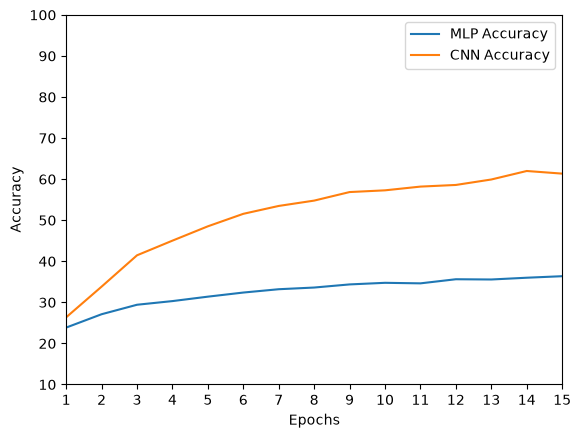

In [ ]:
# reverse the zero indexing
epochs  = 15
x_limits = range(1, epochs  + 1) 

# get csv data as dataframes 
cnn_df = pd.read_csv('logs/cnnlog.csv')
mlp_df = pd.read_csv('logs/mlplog.csv')

# populate logs from csv with accuracies matching the number of epochs (-1 with zero indexing)
cnn_accuracy_log = []
mlp_accuracy_log = []
cnn_accuracy_log = cnn_df.loc[:epochs - 1, "Accuracy"]
mlp_accuracy_log = mlp_df.loc[:epochs - 1, "Accuracy"]

# create graph limits
plt.xlim(1, epochs)
plt.ylim(10, 100)

# creating markings every 10% accuracy and every 1 epoch
plt.xticks(x_limits)
plt.yticks(range(10, 101, 10))

# label the axes
plt.ylabel("Accuracy")
plt.xlabel("Epochs")

plt.plot(x_limits, mlp_accuracy_log, label="MLP Accuracy")
plt.plot(x_limits, cnn_accuracy_log, label="CNN Accuracy")

plt.legend()

plt.show()